# Power Dependence Analysis - MEOP Polarization Data

This notebook analyzes polarization relaxation data from power dependence tests using ROOT/PyROOT for fitting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
import ROOT
from array import array
import math
import os
from pathlib import Path

## Load Data

Load Excel files from the Power Dependence Tests directory and extract metadata from filenames.

In [ ]:
# Directory containing all the data files
data_dir = "/Users/snip/Documents/MEOP/Power Dependence Tests"
output_dir = "/Users/snip/Documents/MEOP/power_dependence_plots"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Get all Excel files in the directory
excel_files = list(Path(data_dir).glob("*.xlsx"))
print(f"Found {len(excel_files)} Excel files to process\n")

# Process first file (you can loop through all later)
file_path = str(excel_files[1])
print(f"Processing: {file_path}")

# Extract metadata from filename (e.g., "3W_C8_datagrab1.xlsx")
filename = Path(file_path).stem
parts = filename.split("_")
power = parts[0]  # e.g., "3W"
cell = parts[1]   # e.g., "C8"
datagrab = parts[2]  # e.g., "datagrab1"

print(f"Power: {power}, Cell: {cell}, Datagrab: {datagrab}")

# Read the Excel file
df = pd.read_excel(file_path)

# Drop and rename columns
df.drop(columns=["Time - Voltage (Formula Result)","Polarization (%) - Voltage (Formula Result)"], inplace=True)
df.rename(columns={"Time - Voltage (Formula Result).1":"time","Polarization (%) - Voltage (Formula Result).1":"polarization"}, inplace=True)

Found 37 Excel files to process

Processing: /Users/snip/Documents/MEOP/Power Dependence Tests/3W_C8_datagrab1.xlsx
Power: 3W, Cell: C8, Datagrab: datagrab1


## Time Conversion and Rollover Detection

Convert MM:SS time format to seconds and detect time rollovers (when time resets from 59:59 to 00:00).

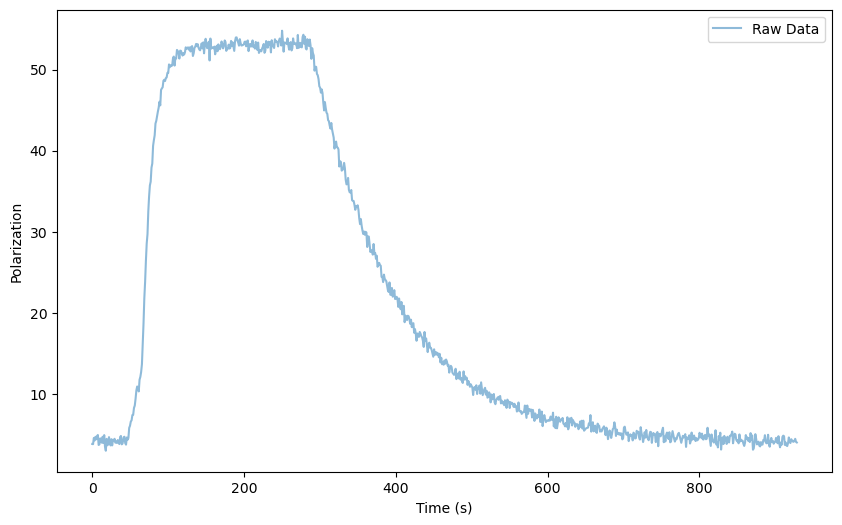

In [3]:
# Convert time string to seconds
def time_to_seconds(time_str):
    parts = str(time_str).split(':')
    if len(parts) == 2:  # MM:SS format
        return int(parts[0]) * 60 + float(parts[1])
    elif len(parts) == 3:  # HH:MM:SS format
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    else:
        return float(time_str)  # Already in seconds

# Convert all times to seconds
time_seconds = df["time"].apply(time_to_seconds).values

# Detect and fix rollovers
corrected_time = [time_seconds[0]]
cumulative_offset = 0

for i in range(1, len(time_seconds)):
    if time_seconds[i] < time_seconds[i-1] - 10:  # Rollover detected
        cumulative_offset += 3600
        print(f"Detected time rollover at index {i}: {time_seconds[i-1]:.1f}s -> {time_seconds[i]:.1f}s (adding {cumulative_offset}s offset)")
    corrected_time.append(time_seconds[i] + cumulative_offset)

df["time"] = corrected_time
df["time"] = df["time"] - df["time"].min()  # Start from zero

# Plot raw data
plt.figure(figsize=(10,6))
plt.plot(df["time"], df["polarization"], label="Raw Data", alpha=0.5)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Polarization")
plt.show()

## Data Smoothing and Relaxation Time Detection

Apply Savitzky-Golay filter and detect decay start point using derivative analysis.

In [4]:
df["smoothed"] = savgol_filter(df["polarization"], 30, 3)
df["derivative"] = np.gradient(df["smoothed"])

# Find global max
global_max_index = df["smoothed"].idxmax()

# Look for where decay consistently starts
decay_start_index = global_max_index
global_max_pol = df["smoothed"][global_max_index]
threshold_10_percent = global_max_pol * 0.9

for i in range(global_max_index, len(df)):
    if i + 5 < len(df):
        if all(df["derivative"].iloc[i:i+5] < 0) and df["smoothed"].iloc[i] <= threshold_10_percent:
            decay_start_index = i
            break

max_index = decay_start_index - 12
max_pol = df["smoothed"][max_index]
min_index = df["smoothed"].idxmin()
min_pol = df["smoothed"][min_index]

print(f"Max index: {max_index}, Min index: {min_index}")

target_value = max_pol / np.e 
print(f"Target value for relaxation: {target_value:.2f}%")

relaxation_data = df.iloc[max_index:min_index+1]
relaxation_data_full = relaxation_data.copy()

relaxation_data = relaxation_data[relaxation_data["smoothed"] > target_value]
relaxation_data_full = relaxation_data_full[relaxation_data_full["smoothed"] > min_pol]
max_time = df["time"][max_index]

if len(relaxation_data) == 0:
    print(f"⚠ Warning: No data points above target value (1/e point)")
    print(f"Using full decay range for analysis")
    relaxation_data = relaxation_data_full
    if len(relaxation_data) < 2:
        print(f"Error: Insufficient data points for relaxation analysis")
        relaxation_time = 0
    else:
        relaxation_time = relaxation_data["time"].iloc[-1] - max_time
else:
    relaxation_time = relaxation_data["time"].iloc[-1] - max_time

print(f"Global max index: {global_max_index}, Decay start index: {decay_start_index}, Selected max index: {max_index}")
print(f"Max polarization (before decay): {max_pol:.2f}%")
print(f"Relaxation time: {relaxation_time:.3f} seconds")

Max index: 273, Min index: 21
Target value for relaxation: 19.37%
⚠ Warning: No data points above target value (1/e point)
Using full decay range for analysis
Error: Insufficient data points for relaxation analysis
Global max index: 264, Decay start index: 285, Selected max index: 273
Max polarization (before decay): 52.65%
Relaxation time: 0.000 seconds


## Four-Phase ROOT Fitting

Fit the data using ROOT with four distinct phases:
1. Initial constant phase
2. Buildup phase (exponential growth)
3. Plateau constant phase
4. Decay phase (exponential decay)

In [6]:
# Fit range configuration
initial_constant_range_min = 0.0
initial_constant_range_max = 102.0

buildup_range_min = 128.0
buildup_range_max = 325.0

constant_range_min = 215.0
constant_range_max = 470.0

decay_range_min = 488.0
decay_range_max = 1069.0

print("="*70)
print("FIT CONFIGURATION")
print("="*70)
print(f"Initial constant fit range: [{initial_constant_range_min}, {initial_constant_range_max}] seconds")
print(f"Buildup fit range:  [{buildup_range_min}, {buildup_range_max}] seconds")
print(f"Constant fit range: [{constant_range_min}, {constant_range_max}] seconds")
print(f"Decay fit range:    [{decay_range_min}, {decay_range_max}] seconds")
print("="*70)

# Prepare full data
time_full = df["time"].values
pol_full = df["polarization"].values

# 1. INITIAL CONSTANT FIT
print("\n" + "="*70)
print("1. INITIAL CONSTANT FIT (before buildup)")
print("="*70)

P_init_const_init = 5.0

mask_init_constant = (time_full >= initial_constant_range_min) & (time_full <= initial_constant_range_max)
time_init_constant = time_full[mask_init_constant]
pol_init_constant = pol_full[mask_init_constant]

if len(time_init_constant) > 0:
    n_init_constant = len(time_init_constant)
    x_init_constant = array('d', time_init_constant.tolist())
    y_init_constant = array('d', pol_init_constant.tolist())
    graph_init_constant = ROOT.TGraph(n_init_constant, x_init_constant, y_init_constant)
    graph_init_constant.SetMarkerStyle(23)
    graph_init_constant.SetMarkerSize(0.8)
    graph_init_constant.SetMarkerColor(ROOT.kBlue)
    
    fit_init_constant = ROOT.TF1("fit_init_constant", "[0]", initial_constant_range_min, initial_constant_range_max)
    fit_init_constant.SetParameter(0, P_init_const_init)
    result_init_constant = graph_init_constant.Fit(fit_init_constant, "RS")
    
    P_init_const_fit = fit_init_constant.GetParameter(0)
    P_init_const_err = fit_init_constant.GetParError(0)
    
    print(f"P_init_const = {P_init_const_fit:.3f} ± {P_init_const_err:.3f} %")
    print(f"Chi2/NDF = {result_init_constant.Chi2():.2f} / {result_init_constant.Ndf()} = {result_init_constant.Chi2()/result_init_constant.Ndf():.3f}")
else:
    print("⚠ No data in initial constant range!")
    graph_init_constant = None
    fit_init_constant = None

# 2. BUILDUP FIT
print("\n" + "="*70)
print("2. BUILDUP PHASE FIT: P_inf - (P_inf - P_int) * exp(-(t-t0)/tau_b)")
print("="*70)

P_offset_init = 10.
P_inf_init = 58.0
P_int_init = 10.0
tau_b_init = 50.0
t_offset_init = buildup_range_min

mask_buildup = (time_full >= buildup_range_min) & (time_full <= buildup_range_max)
time_buildup = time_full[mask_buildup]
pol_buildup = pol_full[mask_buildup]

if len(time_buildup) > 0:
    n_buildup = len(time_buildup)
    x_buildup = array('d', time_buildup.tolist())
    y_buildup = array('d', pol_buildup.tolist())
    graph_buildup = ROOT.TGraph(n_buildup, x_buildup, y_buildup)
    graph_buildup.SetMarkerStyle(21)
    graph_buildup.SetMarkerSize(0.8)
    graph_buildup.SetMarkerColor(ROOT.kGreen+2)
    
    fit_buildup = ROOT.TF1("fit_buildup", "([0] - ([0] - [1]) * exp(-(x-[3])/[2]))+[4]", buildup_range_min, buildup_range_max)
    fit_buildup.SetParName(0, "P_inf")
    fit_buildup.SetParName(1, "P_int")
    fit_buildup.SetParName(2, "tau_b")
    fit_buildup.SetParName(3, "t_offset")
    fit_buildup.SetParName(4,"P_Offset")
    fit_buildup.SetParameter(0, P_inf_init)
    fit_buildup.SetParameter(1, P_int_init)
    fit_buildup.SetParameter(2, tau_b_init)
    fit_buildup.SetParameter(3, t_offset_init)
    fit_buildup.SetParameter(4, P_offset_init)
    
    result_buildup = graph_buildup.Fit(fit_buildup, "RS")
    covar_fit_build = result_buildup.GetCovarianceMatrix()
    print("Covariance Matrix for Phase Build-up")
    covar_fit_build.Print()
    
    P_inf_fit = fit_buildup.GetParameter(0)
    P_int_fit = fit_buildup.GetParameter(1)
    tau_b_fit = fit_buildup.GetParameter(2)
    t_offset_fit = fit_buildup.GetParameter(3)
    P_offset_fit = fit_buildup.GetParameter(4)
    
    P_inf_err = fit_buildup.GetParError(0)
    P_int_err = fit_buildup.GetParError(1)
    tau_b_err = fit_buildup.GetParError(2)
    t_offset_err = fit_buildup.GetParError(3)
    P_offset_err = fit_buildup.GetParError(4)
    
    print(f"P_inf     = {P_inf_fit:.3f} ± {P_inf_err:.3f} % (plateau)")
    print(f"P_int     = {P_int_fit:.3f} ± {P_int_err:.3f} % (initial)")
    print(f"tau_b     = {tau_b_fit:.3f} ± {tau_b_err:.3f} s (buildup time)")
    print(f"t_offset  = {t_offset_fit:.3f} ± {t_offset_err:.3f} s (time offset)")
    print(f"P_offset  = {P_offset_fit:.3f} ± {P_offset_err:.3f} % (P_offset)")
    print(f"Chi2/NDF  = {result_buildup.Chi2():.2f} / {result_buildup.Ndf()} = {result_buildup.Chi2()/result_buildup.Ndf():.3f}")
else:
    print("No data in buildup range!")
    graph_buildup = None
    fit_buildup = None

# 3. PLATEAU CONSTANT FIT
print("\n" + "="*70)
print("3. PLATEAU CONSTANT FIT")
print("="*70)

P_const_init = 70.0

mask_constant = (time_full >= constant_range_min) & (time_full <= constant_range_max)
time_constant = time_full[mask_constant]
pol_constant = pol_full[mask_constant]

if len(time_constant) > 0:
    n_constant = len(time_constant)
    x_constant = array('d', time_constant.tolist())
    y_constant = array('d', pol_constant.tolist())
    graph_constant = ROOT.TGraph(n_constant, x_constant, y_constant)
    graph_constant.SetMarkerStyle(22)
    graph_constant.SetMarkerSize(0.8)
    graph_constant.SetMarkerColor(ROOT.kOrange+7)
    
    fit_constant = ROOT.TF1("fit_plateau_constant", "[0]", constant_range_min, constant_range_max)
    fit_constant.SetParameter(0, P_const_init)
    result_constant = graph_constant.Fit(fit_constant, "RS")
    
    P_const_fit = fit_constant.GetParameter(0)
    P_const_err = fit_constant.GetParError(0)
    
    print(f"P_plateau = {P_const_fit:.3f} ± {P_const_err:.3f} %")
    print(f"Chi2/NDF  = {result_constant.Chi2():.2f} / {result_constant.Ndf()} = {result_constant.Chi2()/result_constant.Ndf():.3f}")
else:
    print("No data in constant range!")
    graph_constant = None
    fit_constant = None

# 4. DECAY FIT
print("\n" + "="*70)
print("4. DECAY FIT")
print("="*70)

P0_init = 55.0
tau_init = 120.0
c_init = 3.0
t_offset_decay_init = 480.0

mask_decay = (time_full >= decay_range_min) & (time_full <= decay_range_max)
time_decay = time_full[mask_decay]
pol_decay = pol_full[mask_decay]

if len(time_decay) > 0:
    n_decay = len(time_decay)
    x_decay = array('d', time_decay.tolist())
    y_decay = array('d', pol_decay.tolist())
    graph_decay = ROOT.TGraph(n_decay, x_decay, y_decay)
    graph_decay.SetMarkerStyle(20)
    graph_decay.SetMarkerSize(0.8)
    graph_decay.SetMarkerColor(ROOT.kRed)
    
    fit_decay = ROOT.TF1("fit_decay", "[0]*exp(-(x-[3])/[1]) + [2]", decay_range_min, decay_range_max)
    fit_decay.SetParName(0, "P0")
    fit_decay.SetParName(1, "tau")
    fit_decay.SetParName(2, "c")
    fit_decay.SetParName(3, "t_offset_decay")
    fit_decay.SetParameter(0, P0_init)
    fit_decay.SetParameter(1, tau_init)
    fit_decay.SetParameter(2, c_init)
    fit_decay.SetParameter(3, t_offset_decay_init)
    
    result_decay = graph_decay.Fit(fit_decay, "RS")
    
    P0_fit = fit_decay.GetParameter(0)
    tau_fit = fit_decay.GetParameter(1)
    c_fit = fit_decay.GetParameter(2)
    t_offset_decay_fit = fit_decay.GetParameter(3)
    
    P0_err = fit_decay.GetParError(0)
    tau_err = fit_decay.GetParError(1)
    c_err = fit_decay.GetParError(2)
    t_offset_decay_err = fit_decay.GetParError(3)
    
    print(f"P0             = {P0_fit:.3f} ± {P0_err:.3f} %")
    print(f"tau            = {tau_fit:.3f} ± {tau_err:.3f} s (decay time)")
    print(f"c              = {c_fit:.3f} ± {c_err:.3f} % (baseline)")
    print(f"t_offset_decay = {t_offset_decay_fit:.3f} ± {t_offset_decay_err:.3f} s (time offset)")
    print(f"Chi2/NDF = {result_decay.Chi2():.2f} / {result_decay.Ndf()} = {result_decay.Chi2()/result_decay.Ndf():.3f}")
else:
    print("⚠ No data in decay range!")
    graph_decay = None
    fit_decay = None

print("\n" + "="*70)

FIT CONFIGURATION
Initial constant fit range: [0.0, 102.0] seconds
Buildup fit range:  [128.0, 325.0] seconds
Constant fit range: [215.0, 470.0] seconds
Decay fit range:    [488.0, 1069.0] seconds

1. INITIAL CONSTANT FIT (before buildup)
P_init_const = 17.579 ± 1.780 %
Chi2/NDF = 29511.47 / 96 = 307.411

2. BUILDUP PHASE FIT: P_inf - (P_inf - P_int) * exp(-(t-t0)/tau_b)
Covariance Matrix for Phase Build-up
P_inf     = -356631.914 ± 114.268 % (plateau)
P_int     = 210003.656 ± 2.569 % (initial)
tau_b     = 16253423.417 ± 3314.265 s (buildup time)
t_offset  = -361122.620 ± 73.685 s (time offset)
P_offset  = -197493.459 ± 2.513 % (P_offset)
Chi2/NDF  = 1357.43 / 183 = 7.418

3. PLATEAU CONSTANT FIT
P_plateau = 35.264 ± 0.952 %
Chi2/NDF  = 53285.70 / 242 = 220.189

4. DECAY FIT
P0             = -299316.908 ± 17.429 %
tau            = -20061518.540 ± 60651.136 s (decay time)
c              = 273843.204 ± 6.492 % (baseline)
t_offset_decay = 1785564.847 ± 3752.779 s (time offset)
Chi2/NDF = 

Warning in <Fit>: Abnormal termination of minimization.


## Combined Plot with Error Bands

Create a comprehensive visualization showing all four fits with uncertainty bands.

In [7]:
print("Creating combined plot...")
print("="*70)

c_combined = ROOT.TCanvas("c_combined", "Four-Phase Fit", 1200, 800)
c_combined.SetGrid()

# Plot full data
x_full = array('d', time_full.tolist())
y_full = array('d', pol_full.tolist())
graph_full = ROOT.TGraph(len(time_full), x_full, y_full)
graph_full.SetTitle("Four-Phase Fit: Initial Constant + Buildup + Plateau + Decay;Time (s);Polarization (%)")
graph_full.SetMarkerStyle(20)
graph_full.SetMarkerSize(0.5)
graph_full.SetMarkerColor(ROOT.kBlack)
graph_full.Draw("AP")

# Function to create error band
def create_error_band(fit_func, x_min, x_max, fit_result, color, n_points=100):
    """Create TGraphErrors uncertainty band by propagating errors from covariance matrix"""
    x_vals = array('d')
    y_vals = array('d')
    ex_vals = array('d')
    ey_vals = array('d')

    cov_matrix = fit_result.GetCovarianceMatrix()
    n_par = fit_func.GetNpar()
    step = (x_max - x_min) / float(n_points)
    grad = array('d', [0.0] * n_par)
    
    for i in range(n_points + 1):
        x = x_min + i * step
        y = fit_func.Eval(x)
        fit_func.GradientPar(array('d', [x]), grad)
        
        variance = 0.0
        for j in range(n_par):
            for k in range(n_par):
                variance += grad[j] * grad[k] * cov_matrix(j, k)
        
        sigma = math.sqrt(abs(variance))
        x_vals.append(x)
        y_vals.append(y)
        ex_vals.append(0.0)
        ey_vals.append(sigma)

    n = len(x_vals)
    error_band = ROOT.TGraphErrors(n, x_vals, y_vals, ex_vals, ey_vals)
    error_band.SetFillColorAlpha(color, 0.3)
    error_band.SetFillStyle(1001)
    error_band.SetLineWidth(0)
    error_band.SetMarkerSize(0)
    
    return error_band

# Draw fits and error bands
if fit_init_constant:
    error_band_init = create_error_band(fit_init_constant, initial_constant_range_min, 
                                        initial_constant_range_max, result_init_constant, ROOT.kBlue)
    error_band_init.Draw("3 SAME")
    fit_init_constant.SetLineColor(ROOT.kBlue)
    fit_init_constant.SetLineWidth(3)
    fit_init_constant.Draw("SAME")
    
if fit_buildup:
    error_band_buildup = create_error_band(fit_buildup, buildup_range_min, 
                                           buildup_range_max, result_buildup, ROOT.kGreen+2)
    error_band_buildup.Draw("3 SAME")
    fit_buildup.SetLineColor(ROOT.kGreen+2)
    fit_buildup.SetLineWidth(3)
    fit_buildup.Draw("SAME")
    
if fit_constant:
    error_band_constant = create_error_band(fit_constant, constant_range_min, 
                                            constant_range_max, result_constant, ROOT.kOrange+7)
    error_band_constant.Draw("3 SAME")
    fit_constant.SetLineColor(ROOT.kOrange+7)
    fit_constant.SetLineWidth(3)
    fit_constant.Draw("SAME")
    
if fit_decay:
    error_band_decay = create_error_band(fit_decay, decay_range_min, 
                                         decay_range_max, result_decay, ROOT.kRed)
    error_band_decay.Draw("3 SAME")
    fit_decay.SetLineColor(ROOT.kRed)
    fit_decay.SetLineWidth(3)
    fit_decay.Draw("SAME")

# Add legend
legend = ROOT.TLegend(0.15, 0.65, 0.40, 0.88)
legend.SetTextSize(0.023)
legend.AddEntry(graph_full, "Data", "p")
if fit_init_constant:
    legend.AddEntry(fit_init_constant, "Initial Constant Fit", "l")
if fit_buildup:
    legend.AddEntry(fit_buildup, "Buildup Fit", "l")
if fit_constant:
    legend.AddEntry(fit_constant, "Plateau Constant Fit", "l")
if fit_decay:
    legend.AddEntry(fit_decay, "Decay Fit", "l")
legend.Draw()

# Add fit parameters text boxes
text_size = 0.035
font = 42

# Box 1: Initial Constant & Buildup
param_box1 = ROOT.TPaveText(0.52, 0.15, 0.72, 0.65, "NDC")
param_box1.SetFillColor(ROOT.kWhite)
param_box1.SetBorderSize(1)
param_box1.SetTextAlign(12)
param_box1.SetTextSize(text_size)
param_box1.SetTextFont(font)

if fit_init_constant:
    param_box1.AddText("#bf{1. Initial Constant Phase}")
    param_box1.AddText("function: P = constant")
    param_box1.AddText(f"P_{{init}} = {P_init_const_fit:.2f} #pm {P_init_const_err:.2f} %")
    param_box1.AddText(f"#chi^{{2}}/NDF = {result_init_constant.Chi2():.2f}/{result_init_constant.Ndf()}")
    param_box1.AddText(" ")

if fit_buildup:
    param_box1.AddText("#bf{2. Buildup Phase}")
    param_box1.AddText("func: P_{#infty} - (P_{#infty}-P_{int})e^{-(t-t_{0})/#tau_{b}} + P_{Offset}")
    param_box1.AddText(f"P_{{#infty}} = {P_inf_fit:.2f} #pm {P_inf_err:.2f} %")
    param_box1.AddText(f"P_{{int}} = {P_int_fit:.2f} #pm {P_int_err:.2f} %")
    param_box1.AddText(f"#tau_{{b}} = {tau_b_fit:.2f} #pm {tau_b_err:.2f} s")
    param_box1.AddText(f"t_{{0}} = {t_offset_fit:.2f} #pm {t_offset_err:.2f} s")
    param_box1.AddText(f"#chi^{{2}}/NDF = {result_buildup.Chi2():.2f}/{result_buildup.Ndf()}")
    param_box1.AddText(f"P_{{offset}} = {P_offset_fit:.2f} #pm {P_offset_err:.2f} %")

# Box 2: Plateau & Decay
param_box2 = ROOT.TPaveText(0.73, 0.15, 0.93, 0.65, "NDC")
param_box2.SetFillColor(ROOT.kWhite)
param_box2.SetBorderSize(1)
param_box2.SetTextAlign(12)
param_box2.SetTextSize(text_size)
param_box2.SetTextFont(font)

if fit_constant:
    param_box2.AddText("#bf{3. Plateau Constant Phase}")
    param_box2.AddText("function: P = constant")
    param_box2.AddText(f"P_{{plateau}} = {P_const_fit:.2f} #pm {P_const_err:.2f} %")
    param_box2.AddText(f"#chi^{{2}}/NDF = {result_constant.Chi2():.2f}/{result_constant.Ndf()}")
    param_box2.AddText(" ")

if fit_decay:
    param_box2.AddText("#bf{4. Decay Phase}")
    param_box2.AddText("func: P_{0}e^{-(t-t_{0d})/#tau} + c")
    param_box2.AddText(f"P_{{0}} = {P0_fit:.2f} #pm {P0_err:.2f} %")
    param_box2.AddText(f"#tau = {tau_fit:.2f} #pm {tau_err:.2f} s")
    param_box2.AddText(f"c = {c_fit:.2f} #pm {c_err:.2f} %")
    param_box2.AddText(f"t_{{0d}} = {t_offset_decay_fit:.2f} #pm {t_offset_decay_err:.2f} s")
    param_box2.AddText(f"#chi^{{2}}/NDF = {result_decay.Chi2():.2f}/{result_decay.Ndf()}")

param_box1.Draw()
param_box2.Draw()

c_combined.Update()
c_combined.Draw()

# Save plot
output_filename_four_phase = f"{filename}_four_phase_fit.png"
output_path = os.path.join(output_dir, output_filename_four_phase)
c_combined.SaveAs(output_path)
print(f"\n✓ Combined plot saved to: {output_path}")

Creating combined plot...

✓ Combined plot saved to: /Users/snip/Documents/MEOP/power_dependence_plots/3W_C8_datagrab1_four_phase_fit.png


Info in <TCanvas::Print>: png file /Users/snip/Documents/MEOP/power_dependence_plots/3W_C8_datagrab1_four_phase_fit.png has been created
